In [1]:
from utils.models import StrongPolicyNet,PolicyNet, ValueNet
from utils.utils_DRL import onehot_encoder
from utils.coin_env import coin_game
import matplotlib.pyplot as plt
from collections import deque
import numpy as np
import random
import psutil
import time
import os
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
# --- SETUP ARSITEKTUR ACTOR-CRITIC ---
actor_model = PolicyNet()  # Instansiasi Aktor (Kebijakan)
critic_model = ValueNet()  # Instansiasi Kritik (Fungsi Nilai)

# Optimizer terpisah untuk masing-masing jaringan
actor_optimizer = optim.Adam(actor_model.parameters(), lr=0.001)
critic_optimizer = optim.Adam(critic_model.parameters(), lr=0.001)

# Menggunakan MSE Loss untuk Critic (memprediksi nilai kontinu expected return)
critic_criterion = nn.MSELoss()

# Model lawan (Sparring Partner)
trained = StrongPolicyNet()                                 
trained.load_state_dict(torch.load('utils/strong_coin.pt')) 
trained.eval()                                              

env = coin_game()

In [3]:
batch_size = 10                  
allstates, alloutcome = [], []   

def opponent(state):
    """Strategi Lawan: 10% peluang blunder (acak) dan 90% berbasis model terlatih."""
    if random.random() < 0.1:
        return random.choice(env.validinputs)
    with torch.no_grad():
        onehot_state = onehot_encoder(state)
        policy = trained(onehot_state).numpy().squeeze()
    return np.random.choice([1, 2, 3], p=policy)  

def playing():
    """Rollout satu episode permainan penuh (Mencatat Log Prob dan State Value)."""
    action_probs_history = []
    state_values_history = []  # Buffer baru untuk menampung V(s) dari Critic
    rewards_history = []
    states = []
    
    state = env.reset()
    episode_reward = 0
    
    while True:
        # --- Giliran Agen Target (Actor-Critic) ---
        onehot_state = onehot_encoder(state)
        
        # 1. Actor memprediksi distribusi tindakan
        action_probs = actor_model(onehot_state)
        action = np.random.choice(3, p=action_probs.detach().numpy().squeeze())
        action_probs_history.append(torch.log(action_probs[0, action]))
        
        # 2. Critic mengevaluasi kualitas state saat ini (V(s))
        # Catatan: Output ValueNet disesuaikan untuk regresi nilai (diambil indeks 0 sebagai nilai state)
        state_value = critic_model(onehot_state)
        state_values_history.append(state_value[0, 0]) 
        
        # Eksekusi langkah agen
        state, reward, done, _ = env.step(action + 1)  
        states.append(state)
        
        if done:
            rewards_history.append(reward); episode_reward += reward; break
            
        # --- Giliran Lawan (Sparring Partner) ---
        state, reward, done, _ = env.step(opponent(state))
        rewards_history.append(reward); episode_reward += reward
        if done: break
                
    return action_probs_history, state_values_history, rewards_history, episode_reward, states, reward

def discount_rs(r, gamma):
    """Perhitungan Reward Discounting (Return G_t) dari belakang ke depan."""
    discounted_rs = np.zeros(len(r))
    running_add = 0
    for i in reversed(range(0, len(r))):
        running_add = gamma * running_add + r[i]  
        discounted_rs[i] = running_add  
    return discounted_rs.tolist()

def create_batch(batch_size, gamma):
    """Pengumpulan data trajectory Actor-Critic ke dalam buffer latihan."""
    action_probs_history = []
    state_values_history = []
    rewards_history = []
    episode_rewards = []
    
    for _ in range(batch_size):
        aps, svs, rs, er, ss, outcome = playing()             
        returns = discount_rs(rs, gamma)                 
        
        action_probs_history += aps
        state_values_history += svs
        rewards_history += returns
        episode_rewards.append(er)
        allstates.append(ss); alloutcome.append(outcome)  
        
    return action_probs_history, state_values_history, rewards_history, episode_rewards

✓ Solved at episode 16140!


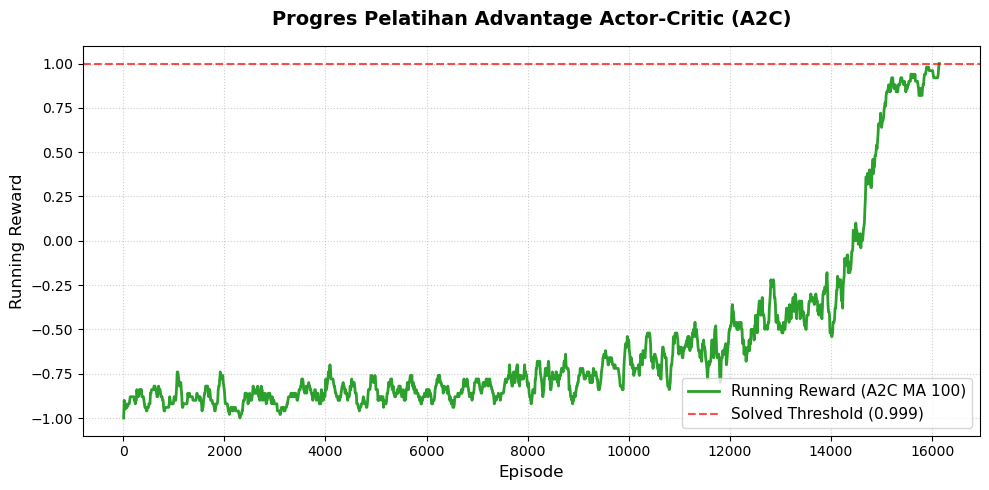

In [4]:
process = psutil.Process(os.getpid())
def get_ram_mb(): return process.memory_info().rss / 1024 / 1024

# Variabel pencatatan
start_time = time.time()
ram_peak = get_ram_mb()
convergence_episode = None

running_rewards = deque(maxlen=100)  
gamma = 0.95                         
episode_count = 0

# Mengatur kedua jaringan ke mode pelatihan aktif
actor_model.train()
critic_model.train()

history_episodes = []
history_rewards = []

# --- SIKLUS PELATIHAN GABUNGAN (ACTOR-CRITIC OPTIMIZATION) ---
while True:
    actor_optimizer.zero_grad()
    critic_optimizer.zero_grad()
    
    # Ambil data batch (Trajectory Buffer)
    action_probs, state_values, returns, episode_rewards = create_batch(batch_size, gamma)
    
    actor_losses = []
    critic_losses = []
    
    for log_prob, state_value, ret in zip(action_probs, state_values, returns):
        # Buat target_return langsung sebagai skalar (tanpa tanda kurung siku [])
        target_return = torch.tensor(ret, dtype=torch.float32)
        
        # --- KUNCI ACTOR-CRITIC: Hitung Advantage ---
        advantage = ret - state_value.item()
        
        # 1. Loss Kebijakan (Actor Loss)
        actor_losses.append(-log_prob * advantage)
        
        # 2. Loss Nilai (Critic Loss) - Sekarang keduanya sudah sama-sama skalar (torch.Size([]))
        critic_losses.append(critic_criterion(state_value, target_return))
        
    # Akumulasi total loss gabungan
    total_actor_loss = torch.stack(actor_losses).sum()
    total_critic_loss = torch.stack(critic_losses).sum()
    
    # Satukan loss (Bisa diberi bobot pembobot jika perlu, misal: total_actor_loss + 0.5 * total_critic_loss)
    total_loss = total_actor_loss + total_critic_loss
    
    # Backpropagation simultan untuk kedua jaringan saraf
    total_loss.backward()
    actor_optimizer.step()
    critic_optimizer.step()
    
    # --- Pembaruan Log Rekam Jejak Pelatihan ---
    episode_count += batch_size
    for r in episode_rewards: running_rewards.append(r)
    running_reward = np.mean(np.array(running_rewards)) 
    
    history_episodes.append(episode_count)
    history_rewards.append(running_reward)

    # --- Kriteria Penghentian (Kondisi Model Telah Konvergen) ---
    if running_reward > 0.999 and episode_count > 100:
        if convergence_episode is None:  # Catat pertama kali saja
            convergence_episode = episode_count
            print(f"✓ Solved at episode {convergence_episode}!")
        break

# Save bobot kedua parameter hasil pelatihan Actor-Critic
torch.save(actor_model.state_dict(), "utils/A2C_actor_coin.pt")
torch.save(critic_model.state_dict(), "utils/A2C_critic_coin.pt")

# --- PROSES PLOTTING DATA PELATIHAN ---
plt.figure(figsize=(10, 5))
plt.plot(history_episodes, history_rewards, label='Running Reward (A2C MA 100)', color='#2ca02c', linewidth=2)
plt.axhline(y=0.999, color='r', linestyle='--', alpha=0.7, label='Solved Threshold (0.999)')
plt.title('Progres Pelatihan Advantage Actor-Critic (A2C)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Running Reward', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.savefig('utils/A2C_training_progress.png', dpi=300, bbox_inches='tight')
plt.show()

# --- EKSPOR METRIK EFISIENSI ---
end_time = time.time()
current_ram = get_ram_mb()
if current_ram > ram_peak:
    ram_peak = current_ram


In [ ]:
print(f"=== METRIK EFISIENSI: A2C (Actor-Critic) ===")
print(f"Waktu Pelatihan   : {end_time - start_time:.2f} detik")
print(f"Episode Konvergen : {convergence_episode if convergence_episode else 'N/A'}")
print(f"Puncak RAM        : {ram_peak:.2f} MB")

=== METRIK EFISIENSI: A2C (Actor-Critic) ===
Waktu Pelatihan   : 393.56 detik
Episode Konvergen : 16140
Puncak RAM        : 319.37 MB
